# 5.8 Q1: Salary Prediction (Train/Test Split)

**Objective:** Predict salary using train-test split

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import os

# Use THIS notebook's folder paths
NOTEBOOK_DIR = os.getcwd()
DATASETS_DIR = os.path.join(NOTEBOOK_DIR, 'datasets')
OUTPUTS_DIR = os.path.join(NOTEBOOK_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

In [2]:
# Load and Split Data
df = pd.read_csv(os.path.join(DATASETS_DIR, 'Salary_Data.csv'))
X = df[['YearsExperience']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 22, Test: 8


In [3]:
# Train and Evaluate
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print("\nSample Predictions:")
for i in range(5):
    print(f"  {X_test[i][0]:.1f} yrs → Pred: ${y_pred[i]:,.0f} | Actual: ${y_test[i]:,.0f}")

R² Score: 0.9347
RMSE: 6229.17

Sample Predictions:
  9.6 yrs → Pred: $115,440 | Actual: $112,635
  4.9 yrs → Pred: $71,396 | Actual: $67,938
  8.2 yrs → Pred: $102,320 | Actual: $113,812
  5.3 yrs → Pred: $75,145 | Actual: $83,088
  3.2 yrs → Pred: $55,465 | Actual: $64,445


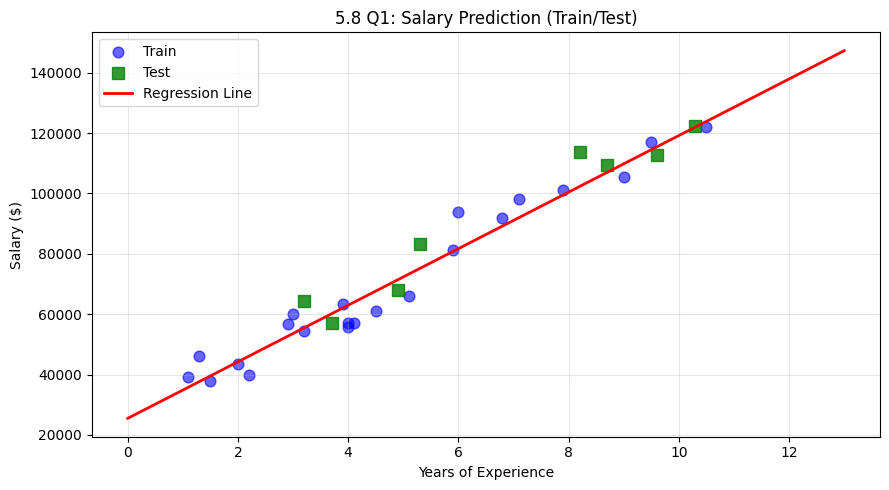

✅ Saved to: /home/z/my-project/ML-Labs-1-2-Final/01-Linear-Regression/outputs/5.8_Q1_Salary_Prediction.png


In [4]:
# Save Output Image
plt.figure(figsize=(9, 5))
plt.scatter(X_train, y_train, color='blue', alpha=0.6, s=60, label='Train')
plt.scatter(X_test, y_test, color='green', alpha=0.8, s=80, marker='s', label='Test')
X_line = np.linspace(0, 13, 100).reshape(-1, 1)
plt.plot(X_line, model.predict(X_line), 'r-', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary ($)')
plt.title('5.8 Q1: Salary Prediction (Train/Test)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, '5.8_Q1_Salary_Prediction.png'), dpi=120)
plt.show()
print(f"✅ Saved to: {OUTPUTS_DIR}/5.8_Q1_Salary_Prediction.png")